# Experiment 1: Feature Representation
In this notebook, we explore different ways to represent text data numerically. The choice of feature representation significantly impacts model performance.

### Techniques to compare:
1. **Bag of Words (BoW)**: Represents text by counting word occurrences.
   - Unigrams (Single words)
   - Bigrams (Pairs of consecutive words)
   - Trigrams (Triplets of consecutive words)
2. **TF-IDF**: Scales BoW by inverse document frequency to down-weight common words.
   - Unigrams, Bigrams, Trigrams
3. **Word2Vec**: Dense vector representations that capture semantic meaning.
   - Average Word2Vec

### Why are we doing this?
- **BoW** is simple but doesn't capture word importance or context.
- **N-grams** (Bigrams/Trigrams) help capture local context (e.g., "not good" vs "good").
- **TF-IDF** highlights unique words in a document.
- **Word2Vec** handles synonyms and semantic similarity better than frequency-based methods.

In [1]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from gensim.models import Word2Vec
import os

# Set MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Feature Representation Exp - 2")

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/04/14 11:15:44 INFO mlflow.tracking.fluent: Experiment with name 'Feature Representation Exp - 2' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/12', creation_time=1776145544664, experiment_id='12', last_update_time=1776145544664, lifecycle_stage='active', name='Feature Representation Exp - 2', tags={}, workspace='default'>

In [2]:
# Load data
data = pd.read_csv(r'../data/processed/dataset.csv')
data = data.dropna(subset=['text_processed', 'sentiment']).drop_duplicates()

X_text = data['text_processed']
X_numeric = data[['char_count', 'word_count', 'avg_word_len']].values
y = data['sentiment']

# Split
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features once for all experiments
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
import tempfile

def run_experiment(name, vectorizer, X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test):
    with mlflow.start_run(run_name=name):
        # Transform text
        if isinstance(vectorizer, str) and vectorizer.startswith("word2vec"):
            strategy = vectorizer.split(":")[1] if ":" in vectorizer else "avg"
            print(f"Word2Vec with strategy: {strategy}")
            
            # Train Word2Vec on train only
            sentences = [text.split() for text in X_text_train]
            w2v_model = Word2Vec(
                sentences,
                vector_size=100,
                window=5,
                min_count=1,
                workers=4,
                seed=42
            )

            def get_w2v_embedding(text_list: list, model: Word2Vec, strategy: str) -> np.ndarray:
                vectors = []
                for text in text_list:
                    if not isinstance(text, str):
                        dim = model.vector_size * 2 if strategy == "concatenate" else model.vector_size
                        vectors.append(np.zeros(dim))
                        continue
                    
                    words = text.split()
                    word_vecs = [model.wv[w] for w in words if w in model.wv]
                    
                    if word_vecs:
                        if strategy == "avg":
                            vectors.append(np.mean(word_vecs, axis=0))
                        elif strategy == "max":
                            vectors.append(np.max(word_vecs, axis=0))
                        elif strategy == "sum":
                            vectors.append(np.sum(word_vecs, axis=0))
                        elif strategy == "concatenate":
                            # Common approach: Concatenate Mean and Max pooling
                            mean_vec = np.mean(word_vecs, axis=0)
                            max_vec = np.max(word_vecs, axis=0)
                            vectors.append(np.concatenate([mean_vec, max_vec]))
                    else:
                        dim = model.vector_size * 2 if strategy == "concatenate" else model.vector_size
                        vectors.append(np.zeros(dim))
                return np.array(vectors)

            X_text_train_arr = np.array(X_text_train.tolist())  
            X_text_test_arr  = np.array(X_text_test.tolist())

            X_train_vec = get_w2v_embedding(X_text_train_arr, w2v_model, strategy)
            X_test_vec  = get_w2v_embedding(X_text_test_arr,  w2v_model, strategy)

            X_train_final = np.hstack([X_train_vec, X_num_train])
            X_test_final = np.hstack([X_test_vec, X_num_test])
        else:
            X_train_vec = vectorizer.fit_transform(X_text_train)
            X_test_vec = vectorizer.transform(X_text_test)
        
            # Combine
            X_train_final = hstack([X_train_vec, X_num_train])
            X_test_final = hstack([X_test_vec, X_num_test])
        
        # Train model
        model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
        model.fit(X_train_final, y_train) # type: ignore
        y_pred = model.predict(X_test_final) # type: ignore
        
        # ── Log Parameters ────────────────────────────────────────────────────────
        mlflow.log_params({
                   # Split
            "test_size"             : 0.2,
            "stratify"              : True,
            "random_state"          : 42,

            # Feature Representation
            "representation"        : name,
            "vectorizer_type"       : type(vectorizer).__name__ if not isinstance(vectorizer, str) else "Word2Vec",
            "pooling_strategy"      : strategy if (isinstance(vectorizer, str) and vectorizer.startswith("word2vec")) else "N/A",

            # Scaling
            "scaler"                : "StandardScaler",
            "scaled_features"       : "char_count, word_count, avg_word_len",

            # Model
            "model"                 : "LogisticRegression",
            "max_iter"              : 1000,
            "solver"                : "lbfgs",
            "random_state"          : 42,
            "class_weight"          : "balanced",

            # Features
            "num_custom_features"   : 3,
            "text_features_count"   : X_train_vec.shape[1] if hasattr(X_train_vec, 'shape') else len(X_train_vec[0]),
        })

        # ── Metrics Calculation ───────────────────────────────────────────────────
        report_dict:dict = classification_report(y_test, y_pred, output_dict=True) #type: ignore
        
        metrics = {
            "accuracy"         : accuracy_score(y_test, y_pred),
            "f1_weighted"      : report_dict['weighted avg']['f1-score'],
            "f1_macro"         : report_dict['macro avg']['f1-score'],
            "precision_weighted": report_dict['weighted avg']['precision'],
            "precision_macro"  : report_dict['macro avg']['precision'],
            "recall_weighted"  : report_dict['weighted avg']['recall'],
            "recall_macro"     : report_dict['macro avg']['recall'],
        }
        
        # ── Log Per-Class Metrics ────────────────────────────────────────────────
        for label in model.classes_:
            metrics[f"f1_class_{label}"] = report_dict[str(label)]['f1-score']
            metrics[f"precision_class_{label}"] = report_dict[str(label)]['precision']
            metrics[f"recall_class_{label}"] = report_dict[str(label)]['recall']
            
        mlflow.log_metrics(metrics)

        # ── Log Classification Report as artifact ─────────────────────────────────
        report_str = classification_report(y_test, y_pred)
        print(report_str)

        with tempfile.TemporaryDirectory() as tmp_dir:
            # ── Classification Report ─────────────────────────────────────────────
            report_path = os.path.join(tmp_dir, "classification_report.txt")
            with open(report_path, 'w') as f:
                f.write(str(report_str))
            mlflow.log_artifact(report_path)

            # ── Confusion Matrix ──────────────────────────────────────────────────
            plt.figure(figsize=(8, 5))
            sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                        xticklabels=model.classes_, yticklabels=model.classes_)
            plt.title(f'Confusion Matrix - {name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.tight_layout()
            
            cm_path = os.path.join(tmp_dir, "confusion_matrix.png")
            plt.savefig(cm_path)
            mlflow.log_artifact(cm_path)
            plt.show()


              precision    recall  f1-score   support

          -1       0.93      0.89      0.91      1029
           0       0.80      0.91      0.85       455
           1       0.90      0.86      0.88       510

    accuracy                           0.89      1994
   macro avg       0.88      0.89      0.88      1994
weighted avg       0.89      0.89      0.89      1994



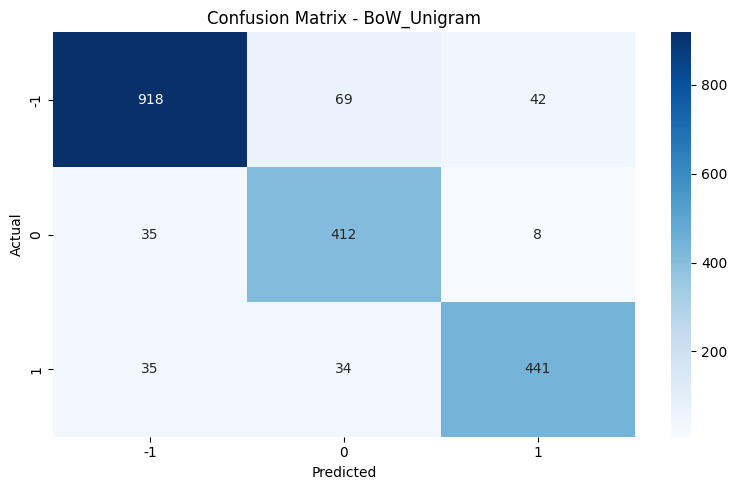

🏃 View run BoW_Unigram at: http://localhost:5000/#/experiments/12/runs/b8c204299173466189f56961ee4b9cb2
🧪 View experiment at: http://localhost:5000/#/experiments/12
              precision    recall  f1-score   support

          -1       0.94      0.89      0.91      1029
           0       0.79      0.91      0.85       455
           1       0.90      0.87      0.88       510

    accuracy                           0.89      1994
   macro avg       0.87      0.89      0.88      1994
weighted avg       0.89      0.89      0.89      1994



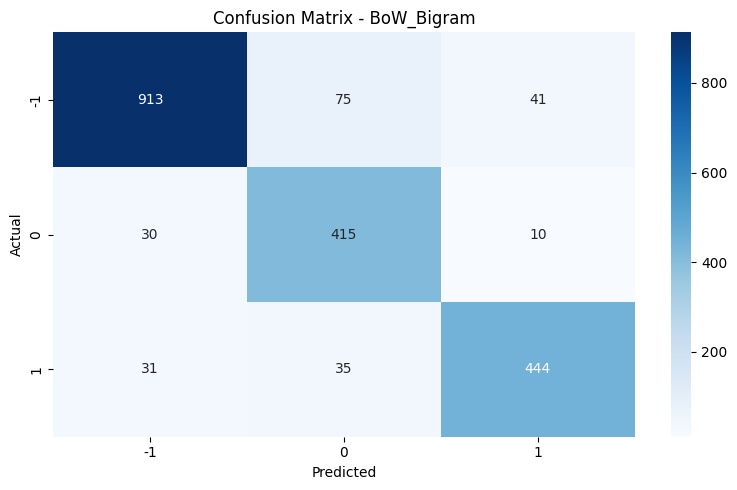

🏃 View run BoW_Bigram at: http://localhost:5000/#/experiments/12/runs/f0801ec98d42474d80f31203d15d8870
🧪 View experiment at: http://localhost:5000/#/experiments/12
              precision    recall  f1-score   support

          -1       0.94      0.89      0.91      1029
           0       0.79      0.91      0.85       455
           1       0.90      0.87      0.88       510

    accuracy                           0.89      1994
   macro avg       0.88      0.89      0.88      1994
weighted avg       0.89      0.89      0.89      1994



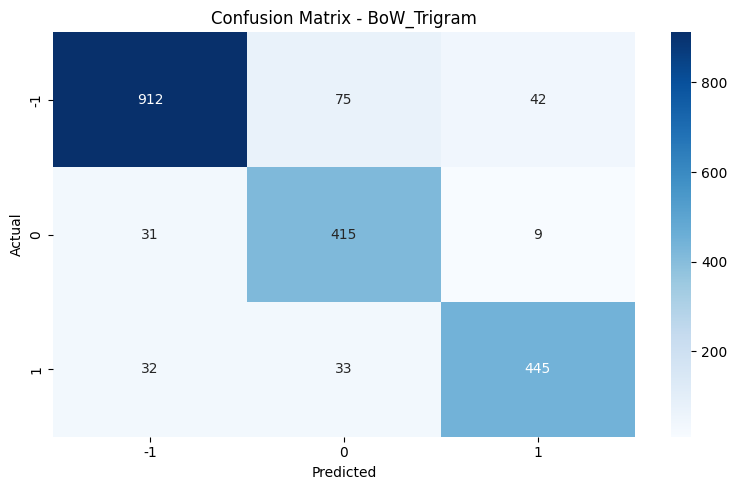

🏃 View run BoW_Trigram at: http://localhost:5000/#/experiments/12/runs/2be566a4d5b34d90a4b53952b66ccf35
🧪 View experiment at: http://localhost:5000/#/experiments/12


In [4]:
# 1. BoW Experiments
run_experiment("BoW_Unigram", CountVectorizer(ngram_range=(1,1), max_features=5000), 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("BoW_Bigram", CountVectorizer(ngram_range=(1,2), max_features=5000), 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("BoW_Trigram", CountVectorizer(ngram_range=(1,3), max_features=5000), 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

              precision    recall  f1-score   support

          -1       0.94      0.89      0.91      1029
           0       0.79      0.91      0.85       455
           1       0.90      0.87      0.88       510

    accuracy                           0.89      1994
   macro avg       0.88      0.89      0.88      1994
weighted avg       0.89      0.89      0.89      1994



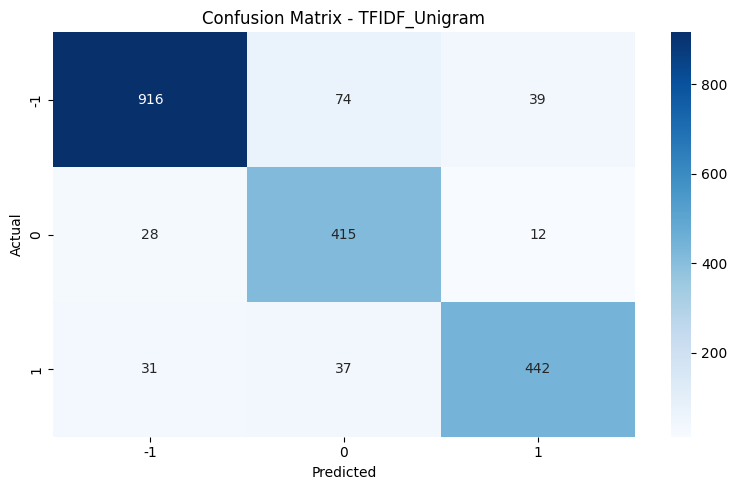

🏃 View run TFIDF_Unigram at: http://localhost:5000/#/experiments/12/runs/5393deb4d6e046a1bca69f05ac9af44e
🧪 View experiment at: http://localhost:5000/#/experiments/12
              precision    recall  f1-score   support

          -1       0.94      0.89      0.92      1029
           0       0.79      0.92      0.85       455
           1       0.91      0.87      0.89       510

    accuracy                           0.89      1994
   macro avg       0.88      0.89      0.89      1994
weighted avg       0.90      0.89      0.89      1994



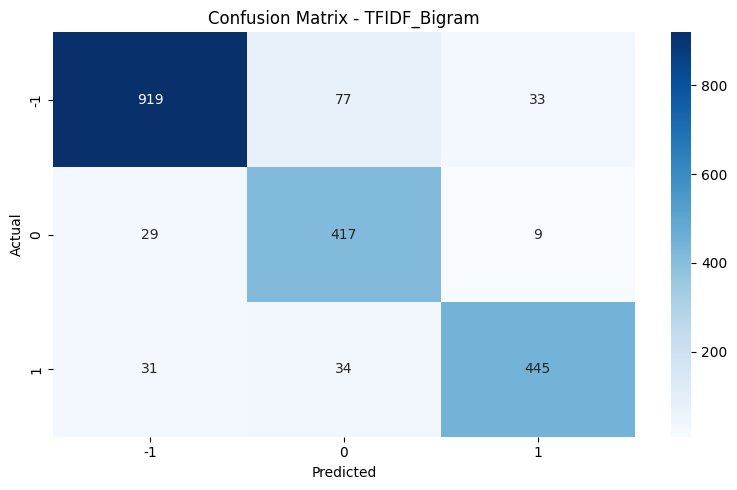

🏃 View run TFIDF_Bigram at: http://localhost:5000/#/experiments/12/runs/5e8ce0b8e7d34e0e8c341aa27b77cfd4
🧪 View experiment at: http://localhost:5000/#/experiments/12
              precision    recall  f1-score   support

          -1       0.94      0.90      0.92      1029
           0       0.79      0.92      0.85       455
           1       0.92      0.88      0.90       510

    accuracy                           0.90      1994
   macro avg       0.88      0.90      0.89      1994
weighted avg       0.90      0.90      0.90      1994



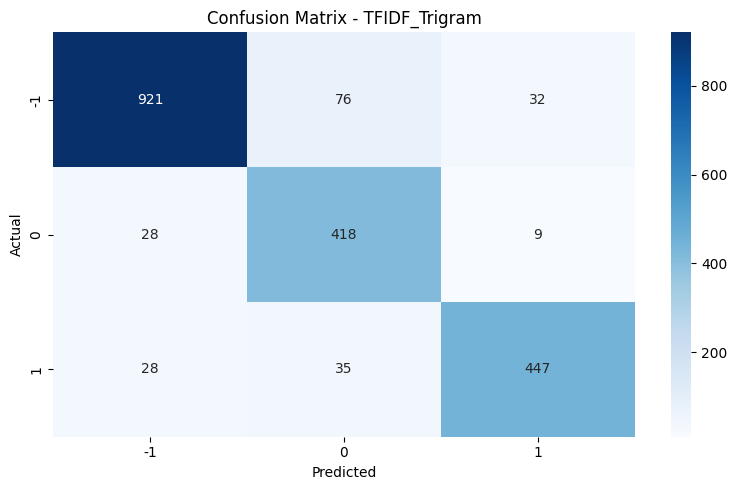

🏃 View run TFIDF_Trigram at: http://localhost:5000/#/experiments/12/runs/bca7e59422074d56ae2d2b898508a1b6
🧪 View experiment at: http://localhost:5000/#/experiments/12


In [5]:
# 2. TF-IDF Experiments
run_experiment("TFIDF_Unigram", TfidfVectorizer(ngram_range=(1,1), max_features=5000), 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("TFIDF_Bigram", TfidfVectorizer(ngram_range=(1,2), max_features=5000), 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("TFIDF_Trigram", TfidfVectorizer(ngram_range=(1,3), max_features=5000), 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)


Word2Vec with strategy: avg
              precision    recall  f1-score   support

          -1       0.85      0.75      0.80      1029
           0       0.53      0.72      0.61       455
           1       0.63      0.57      0.60       510

    accuracy                           0.70      1994
   macro avg       0.67      0.68      0.67      1994
weighted avg       0.72      0.70      0.70      1994



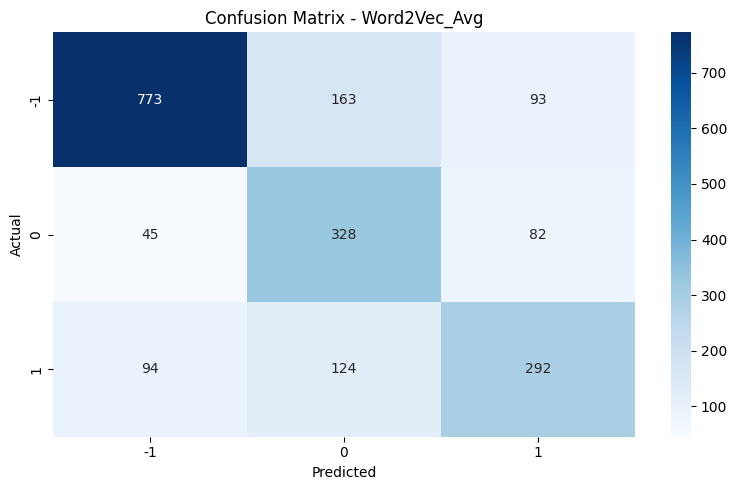

🏃 View run Word2Vec_Avg at: http://localhost:5000/#/experiments/12/runs/137f6ae6c8bc4f9fbefe6368a116a2ed
🧪 View experiment at: http://localhost:5000/#/experiments/12
Word2Vec with strategy: max
              precision    recall  f1-score   support

          -1       0.83      0.70      0.76      1029
           0       0.52      0.70      0.59       455
           1       0.52      0.53      0.52       510

    accuracy                           0.65      1994
   macro avg       0.62      0.64      0.63      1994
weighted avg       0.68      0.65      0.66      1994



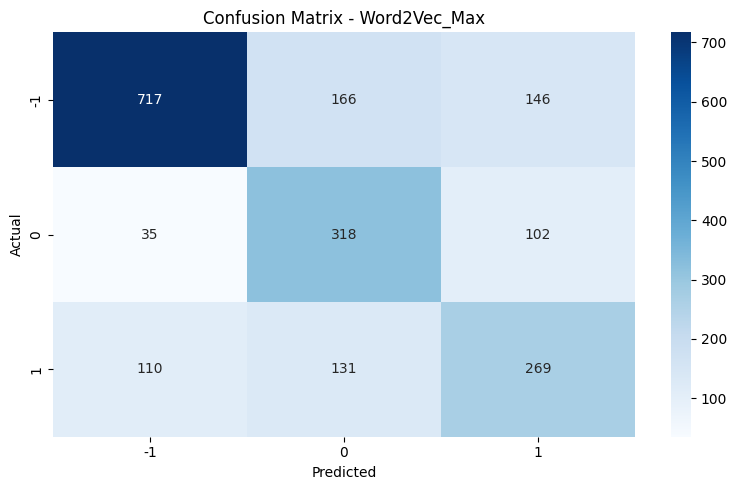

🏃 View run Word2Vec_Max at: http://localhost:5000/#/experiments/12/runs/7527baf755ec4e998aa51b32df00df13
🧪 View experiment at: http://localhost:5000/#/experiments/12
Word2Vec with strategy: sum


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

          -1       0.92      0.73      0.81      1029
           0       0.55      0.89      0.68       455
           1       0.75      0.65      0.70       510

    accuracy                           0.75      1994
   macro avg       0.74      0.76      0.73      1994
weighted avg       0.79      0.75      0.75      1994



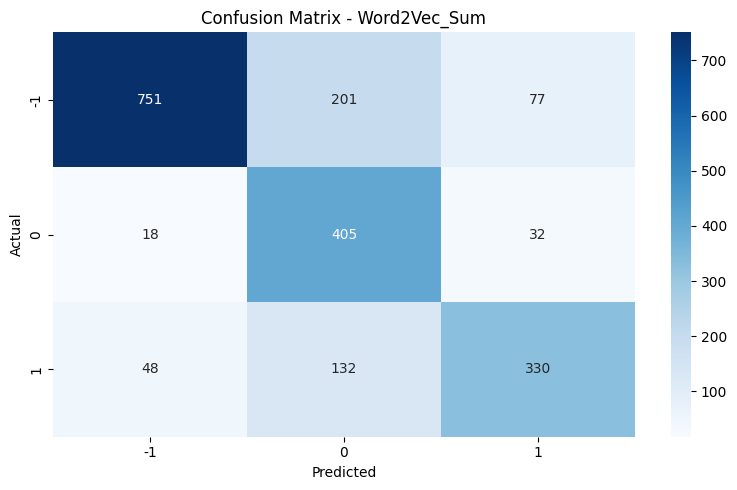

🏃 View run Word2Vec_Sum at: http://localhost:5000/#/experiments/12/runs/e903acf6e77245e6a50949b9b508c0b0
🧪 View experiment at: http://localhost:5000/#/experiments/12
Word2Vec with strategy: concatenate
              precision    recall  f1-score   support

          -1       0.85      0.74      0.79      1029
           0       0.55      0.74      0.63       455
           1       0.61      0.57      0.59       510

    accuracy                           0.70      1994
   macro avg       0.67      0.69      0.67      1994
weighted avg       0.72      0.70      0.70      1994



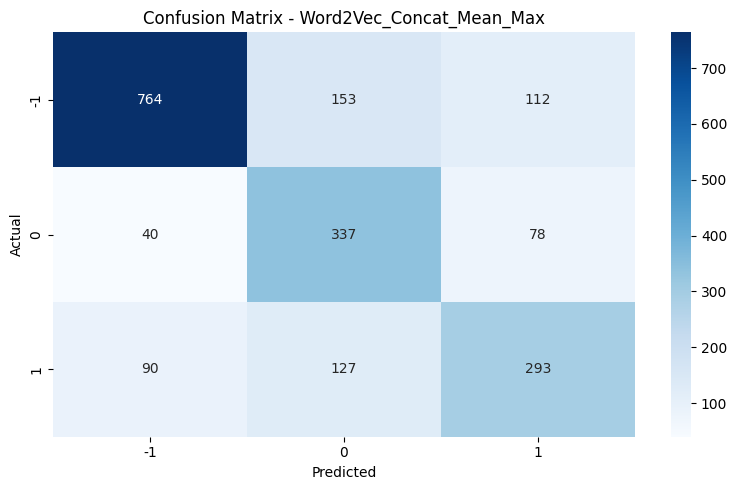

🏃 View run Word2Vec_Concat_Mean_Max at: http://localhost:5000/#/experiments/12/runs/8781ae73e6514e6e85b9880a11558624
🧪 View experiment at: http://localhost:5000/#/experiments/12


In [6]:
# 3. Word2Vec Experiments
run_experiment("Word2Vec_Avg", "word2vec:avg", 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("Word2Vec_Max", "word2vec:max", 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("Word2Vec_Sum", "word2vec:sum", 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)

run_experiment("Word2Vec_Concat_Mean_Max", "word2vec:concatenate", 
               X_text_train, X_text_test, X_num_train_scaled, X_num_test_scaled, y_train, y_test)


#### Conclusion
TFID with Unigram is performing well than others hence the feature reprsentation techq i'm going to use is TFID with UNIGRAM